# ShallowConvNet — reinferencia completa corregida

Esta versión incluye `ShallowClassificationLoss`, necesaria para deserializar correctamente los archivos `fold_result.pkl` guardados por el notebook original.

SHALLOWCONVNET — REINFERENCIA COMPLETA
DATOS PROCESADOS
Device: cpu
X: (8213, 19, 512) float32
y: (8213,) int64
Sujetos: 120
Controles: 60
ADHD: 60
No utilizado: ['v36p']
Window size: 512
Stride: 256
CHECKPOINTS DESCUBIERTOS
Total: 50
Seed 0: /kaggle/input/datasets/alejandragomezr/models-cte-net/resultados_shallowconvnet_tdah_ARTICULO-20260715T223801Z-1-001/resultados_shallowconvnet_tdah_ARTICULO/ShallowConvNet_TDAH_fixed_seed_0
Seed 1: /kaggle/input/datasets/alejandragomezr/models-cte-net/resultados_shallowconvnet_tdah_ARTICULO-20260715T223801Z-1-001/resultados_shallowconvnet_tdah_ARTICULO/ShallowConvNet_TDAH_fixed_seed_1
Seed 2: /kaggle/input/datasets/alejandragomezr/models-cte-net/resultados_shallowconvnet_tdah_ARTICULO-20260715T223801Z-1-001/resultados_shallowconvnet_tdah_ARTICULO/ShallowConvNet_TDAH_fixed_seed_2
Seed 3: /kaggle/input/datasets/alejandragomezr/models-cte-net/resultados_shallowconvnet_tdah_ARTICULO-20260715T223801Z-1-001/resultados_shallowconvnet_tdah_ARTICULO/Shallo

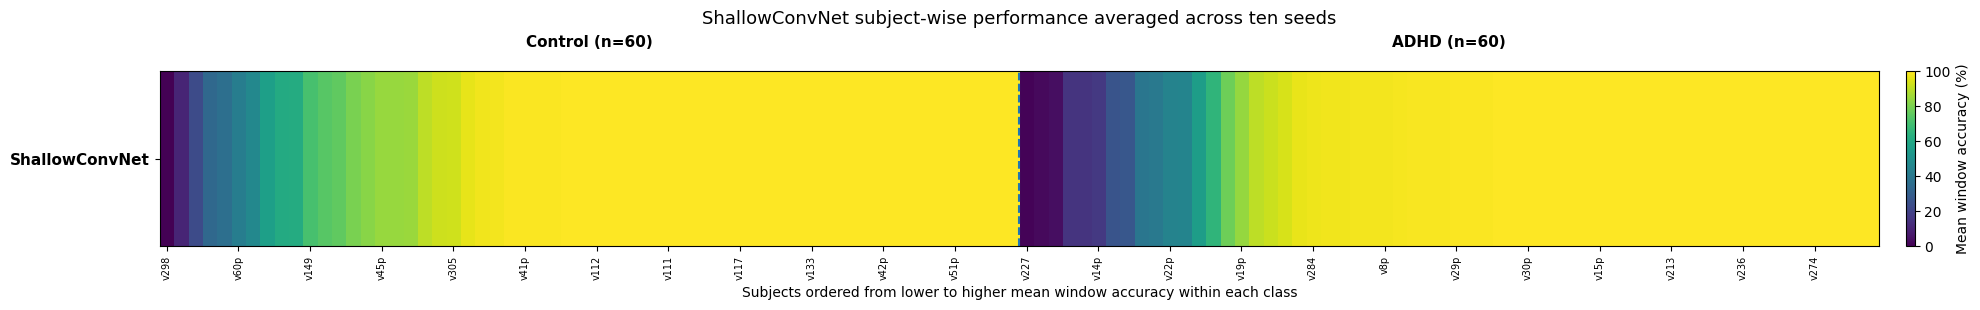


HEATMAP Y ARCHIVOS TIKZ
PNG: /kaggle/working/ShallowConvNet_reinference_complete/figures/ShallowConvNet_heatmap_mean_by_subject.png
PDF: /kaggle/working/ShallowConvNet_reinference_complete/figures/ShallowConvNet_heatmap_mean_by_subject.pdf
DAT: /kaggle/working/ShallowConvNet_reinference_complete/figures/tikz_data/ShallowConvNet_heatmap_mean_by_subject.dat
Ticks: /kaggle/working/ShallowConvNet_reinference_complete/figures/tikz_data/ShallowConvNet_heatmap_subject_ticks.dat
Clases: /kaggle/working/ShallowConvNet_reinference_complete/figures/tikz_data/ShallowConvNet_heatmap_classes.dat
Macros LaTeX: /kaggle/working/ShallowConvNet_reinference_complete/figures/tikz_data/ShallowConvNet_heatmap_axis_settings.tex
Orden CSV: /kaggle/working/ShallowConvNet_reinference_complete/figures/ShallowConvNet_heatmap_subject_order.csv

Proceso finalizado correctamente.


In [2]:

import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import gc
import json
import pickle
import random
import re
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.io
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    recall_score,
    precision_score,
    cohen_kappa_score,
    roc_auc_score,
)


# ============================================================
# 1. RUTAS Y CONFIGURACIÓN
# ============================================================

DATA_ROOT = Path(
    "/kaggle/input/datasets/daprosero/mi-tdah-dataset/"
    "MI_TDAH_Dataset/TDAH"
)

FOLDS_PATH = DATA_ROOT / "folds.pkl"
ADHD_DIR = DATA_ROOT / "ieee/ADHD_group"
CONTROL_DIR = DATA_ROOT / "ieee/Control_group"

MODEL_ROOT = Path(
    "/kaggle/input/datasets/alejandragomezr/models-cte-net/"
    "resultados_shallowconvnet_tdah_ARTICULO-20260715T223801Z-1-001/"
    "resultados_shallowconvnet_tdah_ARTICULO"
)

OUTPUT_ROOT = Path(
    "/kaggle/working/ShallowConvNet_reinference_complete"
)
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

FIGURE_DIR = OUTPUT_ROOT / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

TIKZ_DIR = FIGURE_DIR / "tikz_data"
TIKZ_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

BATCH_SIZE = 64
NUM_WORKERS = 0
N_SEEDS = 10
N_FOLDS = 5
METRIC_TOLERANCE = 1e-6
MODEL_NAME = "ShallowConvNet"


# ============================================================
# 2. REPRODUCIBILIDAD
# ============================================================

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass


# ============================================================
# 3. CARGA Y SEGMENTACIÓN DE LOS 120 SUJETOS
# ============================================================

def clean_subject_id(value):
    if isinstance(value, bytes):
        value = value.decode("utf-8")

    value = Path(str(value)).name

    if value.lower().endswith(".mat"):
        value = value[:-4]

    return value.strip()


def normalize_folds(raw_folds):
    folds = []

    for fold_idx, fold_item in enumerate(raw_folds):
        if isinstance(fold_item, (list, tuple)) and len(fold_item) == 3:
            train_subjects, val_subjects, test_subjects = fold_item

        elif isinstance(fold_item, dict):
            train_subjects = (
                fold_item.get("train")
                or fold_item.get("train_subjects")
                or fold_item.get("subjects_train")
            )
            val_subjects = (
                fold_item.get("val")
                or fold_item.get("validation")
                or fold_item.get("val_subjects")
                or fold_item.get("subjects_val")
            )
            test_subjects = (
                fold_item.get("test")
                or fold_item.get("test_subjects")
                or fold_item.get("subjects_test")
            )

            if (
                train_subjects is None
                or val_subjects is None
                or test_subjects is None
            ):
                raise ValueError(
                    f"No fue posible interpretar el fold {fold_idx}."
                )
        else:
            raise TypeError(
                f"Formato no reconocido para el fold {fold_idx}: "
                f"{type(fold_item)}"
            )

        folds.append(
            (
                [clean_subject_id(x) for x in train_subjects],
                [clean_subject_id(x) for x in val_subjects],
                [clean_subject_id(x) for x in test_subjects],
            )
        )

    return folds


def build_mat_index(directory):
    directory = Path(directory)

    if not directory.exists():
        raise FileNotFoundError(
            f"No existe la carpeta de datos:\n{directory}"
        )

    files = {
        path.stem: path
        for path in sorted(directory.glob("*.mat"))
    }

    if not files:
        raise FileNotFoundError(
            f"No se encontraron archivos .mat en:\n{directory}"
        )

    return files


def load_subject_eeg(mat_path, subject_id, expected_channels=19):
    mat = scipy.io.loadmat(mat_path)

    if subject_id in mat:
        variable_name = subject_id
        raw = np.asarray(mat[subject_id])
    else:
        candidates = []

        for key, value in mat.items():
            if key.startswith("__"):
                continue

            array = np.asarray(value)

            if (
                array.ndim == 2
                and np.issubdtype(array.dtype, np.number)
                and expected_channels in array.shape
            ):
                candidates.append((key, array))

        if not candidates:
            available = {
                key: np.asarray(value).shape
                for key, value in mat.items()
                if not key.startswith("__")
            }
            raise ValueError(
                f"No se encontró una matriz EEG válida en {mat_path}.\n"
                f"Variables disponibles: {available}"
            )

        variable_name, raw = max(
            candidates,
            key=lambda item: item[1].size,
        )

    raw = np.asarray(raw, dtype=np.float32)

    # El notebook original aplicaba data[columna].T.
    eeg = raw.T

    if eeg.shape[0] != expected_channels and raw.shape[0] == expected_channels:
        eeg = raw

    if eeg.shape[0] != expected_channels:
        raise ValueError(
            f"{subject_id}: se esperaban {expected_channels} canales "
            f"y se obtuvo {eeg.shape}."
        )

    if not np.isfinite(eeg).all():
        raise ValueError(
            f"{subject_id}: la señal contiene NaN o Inf."
        )

    return eeg.astype(np.float32), variable_name


def process_adhd_subjects(
    window_size=512,
    overlap=0.50,
):
    with open(FOLDS_PATH, "rb") as file:
        raw_folds = pickle.load(file)

    folds = normalize_folds(raw_folds)

    if len(folds) != N_FOLDS:
        raise ValueError(
            f"Se esperaban {N_FOLDS} folds y se encontraron {len(folds)}."
        )

    protocol_subjects = set()
    test_counter = Counter()

    for fold_idx, (
        train_subjects,
        val_subjects,
        test_subjects,
    ) in enumerate(folds):
        train_set = set(train_subjects)
        val_set = set(val_subjects)
        test_set = set(test_subjects)

        if train_set & val_set:
            raise ValueError(
                f"Fold {fold_idx}: solapamiento train-validation."
            )
        if train_set & test_set:
            raise ValueError(
                f"Fold {fold_idx}: solapamiento train-test."
            )
        if val_set & test_set:
            raise ValueError(
                f"Fold {fold_idx}: solapamiento validation-test."
            )

        protocol_subjects.update(
            train_set | val_set | test_set
        )
        test_counter.update(test_subjects)

    if len(protocol_subjects) != 120:
        raise ValueError(
            f"Se esperaban 120 sujetos en folds.pkl y se encontraron "
            f"{len(protocol_subjects)}."
        )

    invalid_test_counts = {
        subject: count
        for subject, count in test_counter.items()
        if count != 1
    }

    if invalid_test_counts:
        raise ValueError(
            "Cada sujeto debe aparecer exactamente una vez en test: "
            f"{invalid_test_counts}"
        )

    adhd_files = build_mat_index(ADHD_DIR)
    control_files = build_mat_index(CONTROL_DIR)

    repeated = set(adhd_files) & set(control_files)

    if repeated:
        raise ValueError(
            f"Sujetos presentes en ambas clases: {sorted(repeated)}"
        )

    available_subjects = (
        set(adhd_files) | set(control_files)
    )

    missing_subjects = (
        protocol_subjects - available_subjects
    )

    if missing_subjects:
        raise FileNotFoundError(
            "Faltan archivos .mat para los sujetos:\n"
            f"{sorted(missing_subjects)}"
        )

    control_subjects = sorted(
        protocol_subjects & set(control_files)
    )
    adhd_subjects = sorted(
        protocol_subjects & set(adhd_files)
    )
    unused_subjects = sorted(
        available_subjects - protocol_subjects
    )

    if len(control_subjects) != 60 or len(adhd_subjects) != 60:
        raise ValueError(
            "La cohorte debe contener 60 controles y 60 sujetos ADHD. "
            f"Se obtuvo Control={len(control_subjects)}, "
            f"ADHD={len(adhd_subjects)}."
        )

    records = (
        [
            (subject, 0, "Control", control_files[subject])
            for subject in control_subjects
        ]
        +
        [
            (subject, 1, "ADHD", adhd_files[subject])
            for subject in adhd_subjects
        ]
    )

    stride = int(round(
        window_size * (1.0 - overlap)
    ))

    if stride <= 0:
        raise ValueError(
            "El stride calculado no es válido."
        )

    windows = []
    labels = []
    subject_ids = []
    window_ids = []
    metadata_rows = []

    global_window_index = 0

    for subject_position, (
        subject_id,
        label,
        class_name,
        mat_path,
    ) in enumerate(records):
        eeg, variable_name = load_subject_eeg(
            mat_path=mat_path,
            subject_id=subject_id,
            expected_channels=19,
        )

        n_samples = eeg.shape[1]

        if n_samples < window_size:
            raise ValueError(
                f"{subject_id}: solo tiene {n_samples} muestras."
            )

        local_window_id = 0

        for start_sample in range(
            0,
            n_samples - window_size + 1,
            stride,
        ):
            end_sample = (
                start_sample + window_size
            )

            windows.append(
                eeg[:, start_sample:end_sample]
            )
            labels.append(label)
            subject_ids.append(subject_id)
            window_ids.append(local_window_id)

            metadata_rows.append({
                "global_window_index": global_window_index,
                "subject_position": subject_position,
                "subject_id": subject_id,
                "label": label,
                "class_name": class_name,
                "window_id": local_window_id,
                "window_name": f"Window {local_window_id + 1}",
                "start_sample": start_sample,
                "end_sample": end_sample,
                "n_recording_samples": n_samples,
                "mat_variable": variable_name,
                "mat_filename": mat_path.name,
            })

            local_window_id += 1
            global_window_index += 1

    X = np.stack(windows).astype(np.float32)
    y_int = np.asarray(labels, dtype=np.int64)
    subject_ids = np.asarray(subject_ids, dtype=str)
    window_ids = np.asarray(window_ids, dtype=np.int64)
    metadata = pd.DataFrame(metadata_rows)

    if len(np.unique(subject_ids)) != 120:
        raise RuntimeError(
            "No se procesaron exactamente 120 sujetos."
        )

    print("=" * 80)
    print("DATOS PROCESADOS")
    print("=" * 80)
    print("Device:", DEVICE)
    print("X:", X.shape, X.dtype)
    print("y:", y_int.shape, y_int.dtype)
    print("Sujetos:", len(np.unique(subject_ids)))
    print("Controles:", len(control_subjects))
    print("ADHD:", len(adhd_subjects))
    print("No utilizado:", unused_subjects)
    print("Window size:", window_size)
    print("Stride:", stride)

    return {
        "X": X,
        "y_int": y_int,
        "y_onehot": np.eye(
            2,
            dtype=np.float32,
        )[y_int],
        "subject_ids": subject_ids,
        "window_ids": window_ids,
        "metadata": metadata,
        "folds": folds,
        "unused_subjects": unused_subjects,
    }




# ============================================================
# CLASE NECESARIA PARA DESERIALIZAR fold_result.pkl
# ============================================================
# El notebook original guardó una instancia de esta clase dentro
# de compile_cfg["loss_fn"]. Aunque no se usa durante la reinferencia,
# pickle necesita encontrar la clase con el mismo nombre al cargar
# fold_result.pkl.

class ShallowClassificationLoss(nn.Module):
    """
    Pérdida original de ShallowConvNet para etiquetas one-hot y
    probabilidades softmax.
    """

    def __init__(self, eps=1e-7):
        super().__init__()
        self.eps = eps

    def forward(self, outputs, y_true):
        y_pred = outputs["out_activation"]
        y_pred = torch.clamp(
            y_pred,
            self.eps,
            1.0 - self.eps,
        )
        loss = -torch.sum(
            y_true * torch.log(y_pred),
            dim=1,
        )
        return loss.mean()


# ============================================================
# 4. ARQUITECTURA SHALLOWCONVNET ORIGINAL
# ============================================================

def square(x):
    return torch.square(x)


def safe_log(x):
    return torch.log(
        torch.clamp(
            x,
            min=1e-7,
            max=10000.0,
        )
    )


class ShallowConvNetTorch(nn.Module):
    def __init__(
        self,
        nb_classes,
        Chans=64,
        Samples=128,
        dropoutRate=0.5,
        version="2017",
        return_dict=True,
    ):
        super().__init__()

        self.nb_classes = nb_classes
        self.Chans = Chans
        self.Samples = Samples
        self.dropoutRate = dropoutRate
        self.version = version
        self.return_dict = return_dict

        if version == "2017":
            bias_spatial = False
            pool = (1, 75)
            stride = (1, 15)
            filters = (1, 25)

        elif version == "2018":
            bias_spatial = True
            pool = (1, 35)
            stride = (1, 7)
            filters = (1, 13)

        else:
            raise ValueError(
                "version debe ser '2017' o '2018'."
            )

        self.pool_size = pool
        self.stride = stride
        self.filters = filters

        self.conv_temporal = nn.Conv2d(
            in_channels=1,
            out_channels=40,
            kernel_size=filters,
            bias=True,
        )

        self.conv_spatial = nn.Conv2d(
            in_channels=40,
            out_channels=40,
            kernel_size=(Chans, 1),
            bias=bias_spatial,
        )

        self.batchnorm = nn.BatchNorm2d(
            num_features=40,
            eps=1e-5,
            momentum=0.9,
        )

        self.avgpool = nn.AvgPool2d(
            kernel_size=pool,
            stride=stride,
        )

        self.dropout = nn.Dropout(
            p=dropoutRate
        )

        temporal_kernel = filters[1]
        pool_kernel = pool[1]
        pool_stride = stride[1]

        width_after_conv = (
            Samples - temporal_kernel + 1
        )

        width_after_pool = (
            (
                width_after_conv
                - pool_kernel
            )
            // pool_stride
        ) + 1

        if width_after_pool <= 0:
            raise ValueError(
                "La dimensión temporal final es inválida."
            )

        flatten_dim = (
            40 * width_after_pool
        )

        self.classifier = nn.Linear(
            in_features=flatten_dim,
            out_features=nb_classes,
            bias=True,
        )

        self._init_weights()

    def _init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Conv2d):
                nn.init.xavier_uniform_(
                    module.weight
                )
                if module.bias is not None:
                    nn.init.zeros_(
                        module.bias
                    )

            elif isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(
                    module.weight
                )
                if module.bias is not None:
                    nn.init.zeros_(
                        module.bias
                    )

            elif isinstance(
                module,
                nn.BatchNorm2d,
            ):
                nn.init.ones_(
                    module.weight
                )
                nn.init.zeros_(
                    module.bias
                )

    @staticmethod
    @torch.no_grad()
    def _apply_max_norm_to_weight(
        weight,
        max_norm_value,
    ):
        weight_view = weight.view(
            weight.shape[0],
            -1,
        )

        norms = weight_view.norm(
            p=2,
            dim=1,
            keepdim=True,
        )

        desired = torch.clamp(
            norms,
            max=max_norm_value,
        )

        scale = desired / (
            1e-7 + norms
        )

        weight.mul_(
            scale.view(
                -1,
                *(
                    [1]
                    * (
                        weight.dim() - 1
                    )
                ),
            )
        )

    @torch.no_grad()
    def apply_max_norm(self):
        self._apply_max_norm_to_weight(
            self.conv_temporal.weight,
            2.0,
        )
        self._apply_max_norm_to_weight(
            self.conv_spatial.weight,
            2.0,
        )
        self._apply_max_norm_to_weight(
            self.classifier.weight,
            0.5,
        )

    def forward(self, x):
        if x.ndim == 3:
            x = x.unsqueeze(1)

        elif (
            x.ndim == 4
            and x.shape[-1] == 1
            and x.shape[1] != 1
        ):
            x = (
                x.permute(
                    0,
                    3,
                    1,
                    2,
                )
                .contiguous()
            )

        x = self.conv_temporal(x)
        x = self.conv_spatial(x)
        x = self.batchnorm(x)
        x = square(x)
        x = self.avgpool(x)
        x = safe_log(x)
        x = self.dropout(x)
        x = torch.flatten(
            x,
            start_dim=1,
        )

        logits = self.classifier(x)
        probabilities = F.softmax(
            logits,
            dim=1,
        )

        if self.return_dict:
            return {
                "logits": logits,
                "out_activation": probabilities,
            }

        return probabilities


# ============================================================
# 5. CARGA DE CHECKPOINTS
# ============================================================

def safe_torch_load(path):
    try:
        return torch.load(
            path,
            map_location="cpu",
            weights_only=True,
        )
    except TypeError:
        return torch.load(
            path,
            map_location="cpu",
        )
    except Exception:
        return torch.load(
            path,
            map_location="cpu",
            weights_only=False,
        )


def load_state_dict_file(path):
    loaded = safe_torch_load(path)

    if not isinstance(loaded, dict):
        raise TypeError(
            f"El checkpoint no contiene un diccionario: {path}"
        )

    if "model_state_dict" in loaded:
        state_dict = loaded["model_state_dict"]
    elif "state_dict" in loaded:
        state_dict = loaded["state_dict"]
    else:
        state_dict = loaded

    cleaned = {}

    for key, value in state_dict.items():
        clean_key = key

        for prefix in (
            "module.",
            "_orig_mod.",
        ):
            if clean_key.startswith(prefix):
                clean_key = clean_key[
                    len(prefix):
                ]

        cleaned[clean_key] = value

    return cleaned


def extract_seed_from_path(path):
    path_string = str(path)

    patterns = [
        r"ShallowConvNet_TDAH_fixed_seed_(\d+)",
        r"shallowconvnet.*fixed_seed_(\d+)",
        r"fixed_seed_(\d+)",
        r"seed[_-](\d+)",
    ]

    for pattern in patterns:
        match = re.search(
            pattern,
            path_string,
            flags=re.IGNORECASE,
        )

        if match:
            return int(
                match.group(1)
            )

    return None


def extract_fold_from_path(path):
    matches = re.findall(
        r"fold_(\d+)",
        str(path),
        flags=re.IGNORECASE,
    )

    if not matches:
        return None

    return int(matches[-1])


def checkpoint_priority(path):
    filename = path.name.lower()

    if filename == "best_state.pt":
        return 100

    if filename == "final_state_dict.pt":
        return 50

    return 0


def discover_checkpoints(model_root):
    if not model_root.exists():
        raise FileNotFoundError(
            f"No existe la carpeta de modelos:\n{model_root}"
        )

    candidates = {}

    for filename in (
        "best_state.pt",
        "final_state_dict.pt",
    ):
        for checkpoint_path in model_root.rglob(
            filename
        ):
            seed = extract_seed_from_path(
                checkpoint_path
            )
            fold = extract_fold_from_path(
                checkpoint_path
            )

            if seed is None or fold is None:
                continue

            if not (0 <= seed < N_SEEDS):
                continue

            if not (0 <= fold < N_FOLDS):
                continue

            candidates.setdefault(
                (seed, fold),
                [],
            ).append(
                checkpoint_path
            )

    mapping = {}

    for key, checkpoint_paths in candidates.items():
        mapping[key] = max(
            checkpoint_paths,
            key=checkpoint_priority,
        )

    expected = {
        (seed, fold)
        for seed in range(N_SEEDS)
        for fold in range(N_FOLDS)
    }

    missing = sorted(
        expected - set(mapping)
    )

    if missing:
        discovered = sorted(
            str(path)
            for filename in (
                "best_state.pt",
                "final_state_dict.pt",
            )
            for path in model_root.rglob(
                filename
            )
        )

        raise FileNotFoundError(
            "No se encontraron los 50 checkpoints esperados.\n"
            f"Combinaciones faltantes: {missing}\n\n"
            "Checkpoints descubiertos:\n"
            + "\n".join(discovered)
        )

    print("=" * 80)
    print("CHECKPOINTS DESCUBIERTOS")
    print("=" * 80)
    print("Total:", len(mapping))

    for seed in range(N_SEEDS):
        seed_paths = [
            mapping[(seed, fold)]
            for fold in range(N_FOLDS)
        ]

        common_parent = Path(
            os.path.commonpath(
                [
                    str(path.parent)
                    for path in seed_paths
                ]
            )
        )

        print(
            f"Seed {seed}: {common_parent}"
        )

    return mapping


def load_saved_fold_result(
    checkpoint_path,
):
    fold_directory = (
        checkpoint_path.parent
    )

    result_path = (
        fold_directory
        / "fold_result.pkl"
    )

    if not result_path.exists():
        raise FileNotFoundError(
            f"No se encontró:\n{result_path}"
        )

    with open(
        result_path,
        "rb",
    ) as file:
        result = pickle.load(file)

    if (
        "fold_metrics" not in result
        or result["fold_metrics"] is None
    ):
        raise KeyError(
            f"{result_path} no contiene fold_metrics válidas."
        )

    return result


# ============================================================
# 6. INFERENCIA Y MÉTRICAS
# ============================================================

def get_test_partition(
    data,
    fold_idx,
):
    test_subjects = (
        data["folds"][fold_idx][2]
    )

    mask = np.isin(
        data["subject_ids"],
        np.asarray(
            test_subjects,
            dtype=str,
        ),
    )

    test_data = {
        "X": data["X"][mask],
        "y": data["y_int"][mask],
        "subject_ids": (
            data["subject_ids"][mask]
        ),
        "window_ids": (
            data["window_ids"][mask]
        ),
        "metadata": (
            data["metadata"]
            .loc[mask]
            .reset_index(drop=True)
            .copy()
        ),
        "test_subjects": test_subjects,
    }

    n_test_subjects = len(
        np.unique(
            test_data["subject_ids"]
        )
    )

    if n_test_subjects != 24:
        raise ValueError(
            f"Fold {fold_idx}: se esperaban 24 sujetos "
            f"y se encontraron {n_test_subjects}."
        )

    return test_data


def infer_shallowconvnet(
    model,
    X,
    batch_size=BATCH_SIZE,
):
    dataset = TensorDataset(
        torch.from_numpy(
            np.asarray(
                X,
                dtype=np.float32,
            )
        )
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

    probability_batches = []

    model.eval()

    with torch.inference_mode():
        for (batch_x,) in loader:
            batch_x = batch_x.to(
                device=DEVICE,
                dtype=torch.float32,
                non_blocking=True,
            )

            output = model(batch_x)

            if isinstance(output, dict):
                probabilities = output[
                    "out_activation"
                ]
            else:
                probabilities = output

            probability_batches.append(
                probabilities
                .detach()
                .cpu()
                .numpy()
            )

    probabilities = np.concatenate(
        probability_batches,
        axis=0,
    ).astype(np.float32)

    probability_adhd = (
        probabilities[:, 1]
    )

    predictions = np.argmax(
        probabilities,
        axis=1,
    ).astype(np.int64)

    return (
        probabilities,
        probability_adhd,
        predictions,
    )


def calculate_metrics(
    y_true,
    y_pred,
    y_prob,
):
    y_true = np.asarray(
        y_true,
        dtype=np.int64,
    )
    y_pred = np.asarray(
        y_pred,
        dtype=np.int64,
    )
    y_prob = np.asarray(
        y_prob,
        dtype=np.float64,
    )

    try:
        auc_value = roc_auc_score(
            y_true,
            y_prob,
        )
    except ValueError:
        auc_value = np.nan

    return {
        "accuracy": float(
            accuracy_score(
                y_true,
                y_pred,
            )
        ),
        "balanced_accuracy": float(
            balanced_accuracy_score(
                y_true,
                y_pred,
            )
        ),
        "recall": float(
            recall_score(
                y_true,
                y_pred,
                average="binary",
                zero_division=0,
            )
        ),
        "precision": float(
            precision_score(
                y_true,
                y_pred,
                average="binary",
                zero_division=0,
            )
        ),
        "kappa": float(
            cohen_kappa_score(
                y_true,
                y_pred,
            )
        ),
        "auc": float(
            auc_value
        ),
    }


def summarize_values(values):
    values = np.asarray(
        values,
        dtype=float,
    )

    return {
        "mean": float(
            np.nanmean(values)
        ),
        "std_population": float(
            np.nanstd(
                values,
                ddof=0,
            )
        ),
        "std_sample": float(
            np.nanstd(
                values,
                ddof=1,
            )
        ) if len(values) > 1 else 0.0,
        "n": int(len(values)),
    }


# ============================================================
# 7. REINFERENCIA: 10 SEEDS × 5 FOLDS
# ============================================================

def run_all_reinference(data):
    checkpoints = discover_checkpoints(
        MODEL_ROOT
    )

    test_cache = {
        fold: get_test_partition(
            data,
            fold,
        )
        for fold in range(N_FOLDS)
    }

    window_frames = []
    subject_frames = []
    fold_metric_rows = []
    comparison_rows = []

    metric_names = [
        "accuracy",
        "balanced_accuracy",
        "recall",
        "precision",
        "kappa",
        "auc",
    ]

    for seed in range(N_SEEDS):
        for fold in range(N_FOLDS):
            checkpoint_path = (
                checkpoints[(seed, fold)]
            )

            saved_result = (
                load_saved_fold_result(
                    checkpoint_path
                )
            )

            saved_metrics = (
                saved_result["fold_metrics"]
            )

            model_args = dict(
                saved_result.get(
                    "model_args",
                    {},
                )
            )

            if not model_args:
                model_args = {
                    "nb_classes": 2,
                    "Chans": 19,
                    "Samples": 512,
                    "dropoutRate": 0.5,
                    "version": "2018",
                    "return_dict": True,
                }

            model_args.pop(
                "seed",
                None,
            )

            set_seed(
                seed + fold
            )

            model = ShallowConvNetTorch(
                **model_args
            ).to(DEVICE)

            state_dict = load_state_dict_file(
                checkpoint_path
            )

            model.load_state_dict(
                state_dict,
                strict=True,
            )

            test = test_cache[fold]

            (
                probabilities,
                probability_adhd,
                predictions,
            ) = infer_shallowconvnet(
                model=model,
                X=test["X"],
                batch_size=BATCH_SIZE,
            )

            current_metrics = (
                calculate_metrics(
                    y_true=test["y"],
                    y_pred=predictions,
                    y_prob=probability_adhd,
                )
            )

            print(
                f"seed={seed} fold={fold} | "
                f"guardado={float(saved_metrics['accuracy']):.10f} | "
                f"recalculado={current_metrics['accuracy']:.10f}"
            )

            comparison_row = {
                "model": MODEL_NAME,
                "seed": seed,
                "fold": fold,
                "checkpoint_path": str(
                    checkpoint_path
                ),
            }

            metric_matches = []

            for metric in metric_names:
                saved_value = float(
                    saved_metrics[metric]
                )
                current_value = float(
                    current_metrics[metric]
                )

                metric_match = bool(
                    np.isclose(
                        saved_value,
                        current_value,
                        atol=METRIC_TOLERANCE,
                        rtol=0.0,
                        equal_nan=True,
                    )
                )

                comparison_row[
                    f"saved_{metric}"
                ] = saved_value

                comparison_row[
                    f"recomputed_{metric}"
                ] = current_value

                comparison_row[
                    f"difference_{metric}"
                ] = (
                    current_value
                    - saved_value
                )

                comparison_row[
                    f"match_{metric}"
                ] = metric_match

                metric_matches.append(
                    metric_match
                )

            comparison_row[
                "all_metrics_match"
            ] = bool(
                all(metric_matches)
            )

            comparison_rows.append(
                comparison_row
            )

            metadata = test["metadata"]

            window_frame = pd.DataFrame({
                "model": MODEL_NAME,
                "seed": seed,
                "fold": fold,
                "global_window_index": (
                    metadata[
                        "global_window_index"
                    ].to_numpy()
                ),
                "subject_id": (
                    test["subject_ids"]
                ),
                "label": test["y"],
                "class_name": np.where(
                    test["y"] == 1,
                    "ADHD",
                    "Control",
                ),
                "window_id": (
                    test["window_ids"]
                ),
                "window_name": (
                    metadata[
                        "window_name"
                    ].to_numpy()
                ),
                "start_sample": (
                    metadata[
                        "start_sample"
                    ].to_numpy()
                ),
                "end_sample": (
                    metadata[
                        "end_sample"
                    ].to_numpy()
                ),
                "y_true": test["y"],
                "prob_control": (
                    probabilities[:, 0]
                ),
                "prob_adhd": (
                    probabilities[:, 1]
                ),
                "y_pred": predictions,
                "correct": (
                    predictions
                    == test["y"]
                ).astype(np.int64),
            })

            window_frames.append(
                window_frame
            )

            subject_frame = (
                window_frame
                .groupby(
                    [
                        "model",
                        "seed",
                        "fold",
                        "subject_id",
                        "label",
                        "class_name",
                    ],
                    as_index=False,
                )
                .agg(
                    n_windows=(
                        "correct",
                        "size",
                    ),
                    n_correct_windows=(
                        "correct",
                        "sum",
                    ),
                    window_accuracy=(
                        "correct",
                        "mean",
                    ),
                    mean_prob_adhd=(
                        "prob_adhd",
                        "mean",
                    ),
                    std_prob_adhd=(
                        "prob_adhd",
                        "std",
                    ),
                )
            )

            subject_frames.append(
                subject_frame
            )

            fold_metric_rows.append({
                "model": MODEL_NAME,
                "seed": seed,
                "fold": fold,
                "n_test_windows": int(
                    len(test["y"])
                ),
                "n_test_subjects": int(
                    len(
                        np.unique(
                            test["subject_ids"]
                        )
                    )
                ),
                **current_metrics,
            })

            del (
                model,
                probabilities,
                probability_adhd,
                predictions,
            )

            gc.collect()

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    window_predictions = pd.concat(
        window_frames,
        ignore_index=True,
    )

    subject_by_seed = pd.concat(
        subject_frames,
        ignore_index=True,
    )

    fold_metrics = pd.DataFrame(
        fold_metric_rows
    )

    comparisons = pd.DataFrame(
        comparison_rows
    )

    subject_accuracy = (
        subject_by_seed
        .groupby(
            [
                "model",
                "subject_id",
                "label",
                "class_name",
            ],
            as_index=False,
        )
        .agg(
            fold=(
                "fold",
                "first",
            ),
            n_seeds=(
                "seed",
                "nunique",
            ),
            n_windows_per_seed=(
                "n_windows",
                "first",
            ),
            mean_window_accuracy=(
                "window_accuracy",
                "mean",
            ),
            std_window_accuracy=(
                "window_accuracy",
                "std",
            ),
            median_window_accuracy=(
                "window_accuracy",
                "median",
            ),
            min_window_accuracy=(
                "window_accuracy",
                "min",
            ),
            max_window_accuracy=(
                "window_accuracy",
                "max",
            ),
            mean_prob_adhd=(
                "mean_prob_adhd",
                "mean",
            ),
        )
    )

    subject_accuracy[
        "mean_window_accuracy_percent"
    ] = (
        100.0
        * subject_accuracy[
            "mean_window_accuracy"
        ]
    )

    subject_accuracy[
        "std_window_accuracy_percent"
    ] = (
        100.0
        * subject_accuracy[
            "std_window_accuracy"
        ]
    )

    summary_50_rows = []

    for metric in metric_names:
        values = fold_metrics[
            metric
        ].to_numpy(dtype=float)

        summary = summarize_values(
            values
        )

        summary_50_rows.append({
            "metric": metric,
            **summary,
        })

    summary_50 = pd.DataFrame(
        summary_50_rows
    )

    seed_metrics = (
        fold_metrics
        .groupby(
            [
                "model",
                "seed",
            ],
            as_index=False,
        )[metric_names]
        .mean()
    )

    summary_10_rows = []

    for metric in metric_names:
        summary = summarize_values(
            seed_metrics[
                metric
            ].to_numpy(dtype=float)
        )

        summary_10_rows.append({
            "metric": metric,
            **summary,
        })

    summary_10 = pd.DataFrame(
        summary_10_rows
    )

    if len(fold_metrics) != 50:
        raise RuntimeError(
            f"Se esperaban 50 folds y se obtuvieron {len(fold_metrics)}."
        )

    if len(subject_by_seed) != 1200:
        raise RuntimeError(
            "Se esperaban 1200 filas por sujeto y seed, "
            f"pero se obtuvieron {len(subject_by_seed)}."
        )

    if len(subject_accuracy) != 120:
        raise RuntimeError(
            "Se esperaban 120 sujetos finales, "
            f"pero se obtuvieron {len(subject_accuracy)}."
        )

    output_paths = {
        "window_predictions": (
            OUTPUT_ROOT
            / "ShallowConvNet_all_window_predictions.csv"
        ),
        "subject_by_seed": (
            OUTPUT_ROOT
            / "ShallowConvNet_subject_summary_by_seed.csv"
        ),
        "subject_accuracy": (
            OUTPUT_ROOT
            / "ShallowConvNet_subject_accuracy_across_seeds.csv"
        ),
        "fold_metrics": (
            OUTPUT_ROOT
            / "ShallowConvNet_fold_metrics_recomputed.csv"
        ),
        "comparisons": (
            OUTPUT_ROOT
            / "ShallowConvNet_saved_vs_recomputed_metrics.csv"
        ),
        "summary_50": (
            OUTPUT_ROOT
            / "ShallowConvNet_summary_50_runs.csv"
        ),
        "seed_metrics": (
            OUTPUT_ROOT
            / "ShallowConvNet_seed_metrics_mean_of_folds.csv"
        ),
        "summary_10": (
            OUTPUT_ROOT
            / "ShallowConvNet_summary_across_10_seeds.csv"
        ),
    }

    window_predictions.to_csv(
        output_paths[
            "window_predictions"
        ],
        index=False,
    )

    subject_by_seed.to_csv(
        output_paths[
            "subject_by_seed"
        ],
        index=False,
    )

    subject_accuracy.to_csv(
        output_paths[
            "subject_accuracy"
        ],
        index=False,
    )

    fold_metrics.to_csv(
        output_paths[
            "fold_metrics"
        ],
        index=False,
    )

    comparisons.to_csv(
        output_paths[
            "comparisons"
        ],
        index=False,
    )

    summary_50.to_csv(
        output_paths[
            "summary_50"
        ],
        index=False,
    )

    seed_metrics.to_csv(
        output_paths[
            "seed_metrics"
        ],
        index=False,
    )

    summary_10.to_csv(
        output_paths[
            "summary_10"
        ],
        index=False,
    )

    all_results_match = bool(
        comparisons[
            "all_metrics_match"
        ].all()
    )

    summary_json = {
        "model": MODEL_NAME,
        "device": str(DEVICE),
        "n_seeds": N_SEEDS,
        "n_folds": N_FOLDS,
        "n_subjects": int(
            subject_accuracy[
                "subject_id"
            ].nunique()
        ),
        "all_metrics_match": all_results_match,
        "summary_50_folds": (
            summary_50
            .to_dict(
                orient="records"
            )
        ),
        "summary_10_seeds": (
            summary_10
            .to_dict(
                orient="records"
            )
        ),
        "output_files": {
            key: str(value)
            for key, value in output_paths.items()
        },
    }

    with open(
        OUTPUT_ROOT
        / "ShallowConvNet_reinference_summary.json",
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            summary_json,
            file,
            indent=2,
            ensure_ascii=False,
        )

    print("\n" + "=" * 80)
    print("RESULTADOS DE REINFERENCIA")
    print("=" * 80)
    print(
        "Todos los resultados guardados coinciden:",
        all_results_match,
    )

    print("\nResumen sobre los 50 folds:")
    print(
        summary_50[
            [
                "metric",
                "mean",
                "std_sample",
                "n",
            ]
        ].to_string(
            index=False
        )
    )

    print("\nResumen entre las diez seeds:")
    print(
        summary_10[
            [
                "metric",
                "mean",
                "std_sample",
                "n",
            ]
        ].to_string(
            index=False
        )
    )

    print(
        "\nArchivos guardados en:",
        OUTPUT_ROOT,
    )

    return {
        "window_predictions": window_predictions,
        "subject_by_seed": subject_by_seed,
        "subject_accuracy": subject_accuracy,
        "fold_metrics": fold_metrics,
        "comparisons": comparisons,
        "summary_50": summary_50,
        "seed_metrics": seed_metrics,
        "summary_10": summary_10,
        "all_results_match": all_results_match,
    }


# ============================================================
# 8. HEATMAP PROMEDIO POR SUJETO Y EXPORTACIÓN TIKZ
# ============================================================

def create_subject_heatmap_and_tikz(
    subject_accuracy,
):
    required_columns = {
        "model",
        "subject_id",
        "label",
        "class_name",
        "fold",
        "n_seeds",
        "mean_window_accuracy_percent",
        "std_window_accuracy_percent",
    }

    missing_columns = (
        required_columns
        - set(subject_accuracy.columns)
    )

    if missing_columns:
        raise KeyError(
            "Faltan columnas para generar el heatmap: "
            f"{sorted(missing_columns)}"
        )

    plot_data = subject_accuracy.copy()

    plot_data[
        "subject_id"
    ] = (
        plot_data[
            "subject_id"
        ].astype(str)
    )

    plot_data[
        "label"
    ] = (
        plot_data[
            "label"
        ].astype(int)
    )

    ordered_data = (
        plot_data
        .sort_values(
            by=[
                "label",
                "mean_window_accuracy_percent",
                "subject_id",
            ],
            ascending=[
                True,
                True,
                True,
            ],
        )
        .reset_index(
            drop=True
        )
    )

    ordered_data.insert(
        0,
        "heatmap_column",
        np.arange(
            1,
            len(ordered_data) + 1,
        ),
    )

    n_control = int(
        (
            ordered_data[
                "label"
            ]
            == 0
        ).sum()
    )

    n_adhd = int(
        (
            ordered_data[
                "label"
            ]
            == 1
        ).sum()
    )

    if (
        n_control != 60
        or n_adhd != 60
    ):
        raise ValueError(
            f"Distribución inesperada: Control={n_control}, ADHD={n_adhd}."
        )

    order_csv_path = (
        FIGURE_DIR
        / "ShallowConvNet_heatmap_subject_order.csv"
    )

    ordered_data[
        [
            "heatmap_column",
            "subject_id",
            "label",
            "class_name",
            "fold",
            "mean_window_accuracy_percent",
            "std_window_accuracy_percent",
        ]
    ].to_csv(
        order_csv_path,
        index=False,
    )

    heatmap_values = (
        ordered_data[
            "mean_window_accuracy_percent"
        ]
        .to_numpy(dtype=float)
        .reshape(1, -1)
    )

    subject_order = (
        ordered_data[
            "subject_id"
        ]
        .tolist()
    )

    fig, ax = plt.subplots(
        figsize=(20, 3.2)
    )

    image = ax.imshow(
        heatmap_values,
        aspect="auto",
        interpolation="nearest",
        cmap="viridis",
        vmin=0,
        vmax=100,
    )

    ax.set_yticks([0])
    ax.set_yticklabels(
        [MODEL_NAME],
        fontsize=11,
        fontweight="bold",
    )

    tick_every = 5

    tick_positions_zero = np.arange(
        0,
        len(subject_order),
        tick_every,
        dtype=int,
    )

    ax.set_xticks(
        tick_positions_zero
    )

    ax.set_xticklabels(
        [
            subject_order[position]
            for position
            in tick_positions_zero
        ],
        rotation=90,
        fontsize=7,
    )

    ax.set_xlim(
        -0.5,
        len(subject_order) - 0.5,
    )

    ax.axvline(
        n_control - 0.5,
        linewidth=1.5,
        linestyle="--",
    )

    ax.text(
        (
            n_control / 2
        )
        / len(subject_order),
        1.12,
        f"Control (n={n_control})",
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

    ax.text(
        (
            n_control
            + n_adhd / 2
        )
        / len(subject_order),
        1.12,
        f"ADHD (n={n_adhd})",
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

    ax.set_xlabel(
        "Subjects ordered from lower to higher mean window accuracy "
        "within each class",
        fontsize=10,
    )

    ax.set_title(
        "ShallowConvNet subject-wise performance averaged across ten seeds",
        fontsize=13,
        pad=34,
    )

    colorbar = fig.colorbar(
        image,
        ax=ax,
        fraction=0.025,
        pad=0.015,
    )

    colorbar.set_label(
        "Mean window accuracy (%)",
        fontsize=10,
    )

    fig.tight_layout()

    heatmap_png_path = (
        FIGURE_DIR
        / "ShallowConvNet_heatmap_mean_by_subject.png"
    )

    heatmap_pdf_path = (
        FIGURE_DIR
        / "ShallowConvNet_heatmap_mean_by_subject.pdf"
    )

    fig.savefig(
        heatmap_png_path,
        dpi=400,
        bbox_inches="tight",
    )

    fig.savefig(
        heatmap_pdf_path,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    dat_data = ordered_data.copy()

    dat_data["x"] = np.arange(
        1,
        len(dat_data) + 1,
    )

    dat_data["y"] = 0.0

    dat_data = (
        dat_data[
            [
                "x",
                "y",
                "subject_id",
                "label",
                "class_name",
                "fold",
                "mean_window_accuracy_percent",
                "std_window_accuracy_percent",
            ]
        ]
        .rename(
            columns={
                "mean_window_accuracy_percent": "accuracy",
                "std_window_accuracy_percent": "std_accuracy",
            }
        )
    )

    heatmap_dat_path = (
        TIKZ_DIR
        / "ShallowConvNet_heatmap_mean_by_subject.dat"
    )

    dat_data.to_csv(
        heatmap_dat_path,
        sep=" ",
        index=False,
        float_format="%.6f",
    )

    ticks_data = pd.DataFrame({
        "x": (
            tick_positions_zero + 1
        ),
        "subject_id": [
            subject_order[position]
            for position
            in tick_positions_zero
        ],
    })

    ticks_dat_path = (
        TIKZ_DIR
        / "ShallowConvNet_heatmap_subject_ticks.dat"
    )

    ticks_data.to_csv(
        ticks_dat_path,
        sep=" ",
        index=False,
    )

    classes_data = pd.DataFrame([
        {
            "class_name": "Control",
            "label": 0,
            "n_subjects": n_control,
            "x_start": 0.5,
            "x_end": n_control + 0.5,
            "x_center": (
                1 + n_control
            ) / 2,
        },
        {
            "class_name": "ADHD",
            "label": 1,
            "n_subjects": n_adhd,
            "x_start": n_control + 0.5,
            "x_end": (
                n_control
                + n_adhd
                + 0.5
            ),
            "x_center": (
                n_control
                + (
                    n_adhd + 1
                ) / 2
            ),
        },
    ])

    classes_dat_path = (
        TIKZ_DIR
        / "ShallowConvNet_heatmap_classes.dat"
    )

    classes_data.to_csv(
        classes_dat_path,
        sep=" ",
        index=False,
        float_format="%.1f",
    )

    latex_xticks = ",".join(
        ticks_data[
            "x"
        ].astype(str)
    )

    latex_xticklabels = ",".join(
        ticks_data[
            "subject_id"
        ].astype(str)
    )

    latex_helper_path = (
        TIKZ_DIR
        / "ShallowConvNet_heatmap_axis_settings.tex"
    )

    with open(
        latex_helper_path,
        "w",
        encoding="utf-8",
    ) as file:
        file.write(
            "% Archivo generado automáticamente\n"
        )
        file.write(
            f"\\def\\ShallowConvNetXTicks{{{latex_xticks}}}\n"
        )
        file.write(
            f"\\def\\ShallowConvNetXTickLabels"
            f"{{{latex_xticklabels}}}\n"
        )
        file.write(
            f"\\def\\ShallowConvNetControlN{{{n_control}}}\n"
        )
        file.write(
            f"\\def\\ShallowConvNetADHDN{{{n_adhd}}}\n"
        )
        file.write(
            f"\\def\\ShallowConvNetClassDivider"
            f"{{{n_control + 0.5}}}\n"
        )
        file.write(
            f"\\def\\ShallowConvNetControlCenter"
            f"{{{(1 + n_control) / 2:.1f}}}\n"
        )
        file.write(
            f"\\def\\ShallowConvNetADHDCenter"
            f"{{{n_control + (n_adhd + 1) / 2:.1f}}}\n"
        )

    if len(dat_data) != 120:
        raise RuntimeError(
            "El archivo DAT no contiene 120 sujetos."
        )

    if not dat_data[
        "accuracy"
    ].between(
        0,
        100,
    ).all():
        raise RuntimeError(
            "Hay accuracies fuera del rango 0-100."
        )

    print("\n" + "=" * 80)
    print("HEATMAP Y ARCHIVOS TIKZ")
    print("=" * 80)
    print("PNG:", heatmap_png_path)
    print("PDF:", heatmap_pdf_path)
    print("DAT:", heatmap_dat_path)
    print("Ticks:", ticks_dat_path)
    print("Clases:", classes_dat_path)
    print("Macros LaTeX:", latex_helper_path)
    print("Orden CSV:", order_csv_path)

    return {
        "ordered_data": ordered_data,
        "heatmap_png": heatmap_png_path,
        "heatmap_pdf": heatmap_pdf_path,
        "heatmap_dat": heatmap_dat_path,
        "ticks_dat": ticks_dat_path,
        "classes_dat": classes_dat_path,
        "latex_helper": latex_helper_path,
        "order_csv": order_csv_path,
    }


# ============================================================
# 9. EJECUCIÓN COMPLETA
# ============================================================

def main():
    print("=" * 80)
    print("SHALLOWCONVNET — REINFERENCIA COMPLETA")
    print("=" * 80)

    data = process_adhd_subjects()

    results = run_all_reinference(
        data
    )

    create_subject_heatmap_and_tikz(
        results[
            "subject_accuracy"
        ]
    )

    print("\nProceso finalizado correctamente.")


if __name__ == "__main__":
    main()
